In [33]:
import numpy as np
import pandas as pd
import datetime as dt
import yfinance as yf
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import statsmodels.api as sm
import statsmodels.tsa.stattools as ts
from statsmodels.tsa.stattools import adfuller
import warnings
warnings.filterwarnings('ignore')

In [34]:
currencies = [
    # G10 / majors
    "EURUSD=X",  # EUR
    "GBPUSD=X",  # GBP
    "AUDUSD=X",  # AUD
    "NZDUSD=X",  # NZD
    "USDJPY=X",  # JPY
    "USDCAD=X",  # CAD
    "USDCHF=X",  # CHF
    "USDNOK=X",  # NOK
    "USDSEK=X",  # SEK
    "USDDKK=X",  # DKK

    # Asia
    "USDINR=X",  # INR
    "USDCNY=X",  # CNY
    "USDHKD=X",  # HKD
    "USDSGD=X",  # SGD
    "USDKRW=X",  # KRW
    "USDTWD=X",  # TWD
    "USDTHB=X",  # THB
    "USDIDR=X",  # IDR
    "USDMYR=X",  # MYR
    "USDPHP=X",  # PHP
    "USDVND=X",  # VND

    # Americas
    "USDMXN=X",  # MXN
    "USDBRL=X",  # BRL
    "USDCLP=X",  # CLP
    "USDCOP=X",  # COP
    "USDPEN=X",  # PEN
    "USDARS=X",  # ARS

    # Europe (non-euro)
    "USDPLN=X",  # PLN
    "USDCZK=X",  # CZK
    "USDHUF=X",  # HUF
    "USDRON=X",  # RON
    "USDTRY=X",  # TRY
    "USDRUB=X",  # RUB

    # Africa & Middle East
    "USDZAR=X",  # ZAR
    "USDEGP=X",  # EGP
    "USDNGN=X",  # NGN
    "USDKES=X",  # KES
    "USDGHS=X",  # GHS
    "USDAED=X",  # AED (pegged)
    "USDSAR=X",  # SAR (pegged)
    "USDQAR=X",  # QAR (pegged)
    "USDKWD=X",  # KWD

    # Central Asia / others
    "USDKZT=X"   # KZT
]

In [35]:
df = yf.download(currencies, start='2016-01-01',auto_adjust=False,multi_level_index=False)['Adj Close']

[*********************100%***********************]  43 of 43 completed


In [36]:
rename_dict = {
    "EURUSD=X": "EUR",
    "GBPUSD=X": "GBP",
    "AUDUSD=X": "AUD",
    "NZDUSD=X": "NZD",
    "USDJPY=X": "JPY",
    "USDCAD=X": "CAD",
    "USDCHF=X": "CHF",
    "USDNOK=X": "NOK",
    "USDSEK=X": "SEK",
    "USDDKK=X": "DKK",

    "USDINR=X": "INR",
    "USDCNY=X": "CNY",
    "USDHKD=X": "HKD",
    "USDSGD=X": "SGD",
    "USDKRW=X": "KRW",
    "USDTWD=X": "TWD",
    "USDTHB=X": "THB",
    "USDIDR=X": "IDR",
    "USDMYR=X": "MYR",
    "USDPHP=X": "PHP",
    "USDVND=X": "VND",

    "USDMXN=X": "MXN",
    "USDBRL=X": "BRL",
    "USDCLP=X": "CLP",
    "USDCOP=X": "COP",
    "USDPEN=X": "PEN",
    "USDARS=X": "ARS",

    "USDPLN=X": "PLN",
    "USDCZK=X": "CZK",
    "USDHUF=X": "HUF",
    "USDRON=X": "RON",
    "USDTRY=X": "TRY",
    "USDRUB=X": "RUB",

    "USDZAR=X": "ZAR",
    "USDEGP=X": "EGP",
    "USDNGN=X": "NGN",
    "USDKES=X": "KES",
    "USDGHS=X": "GHS",
    "USDAED=X": "AED",
    "USDSAR=X": "SAR",
    "USDQAR=X": "QAR",
    "USDKWD=X": "KWD",

    "USDKZT=X": "KZT"
}

In [37]:
df = df.rename(columns=rename_dict)

In [38]:
df.isna().sum()

Ticker
AUD    2
EUR    2
GBP    2
NZD    2
AED    2
ARS    2
BRL    2
CAD    2
CHF    3
CLP    2
CNY    3
COP    0
CZK    2
DKK    2
EGP    2
GHS    2
HKD    2
HUF    3
IDR    2
INR    2
JPY    2
KES    0
KRW    2
KWD    3
KZT    2
MXN    1
MYR    1
NGN    2
NOK    3
PEN    2
PHP    2
PLN    3
QAR    2
RON    2
RUB    2
SAR    3
SEK    2
SGD    2
THB    2
TRY    3
TWD    2
VND    0
ZAR    2
dtype: int64

In [39]:
df[df.isna().any(axis=1)]

Ticker,AUD,EUR,GBP,NZD,AED,ARS,BRL,CAD,CHF,CLP,...,RON,RUB,SAR,SEK,SGD,THB,TRY,TWD,VND,ZAR
Date,,,,,,,,,,,,,,,,,,,,,
2017-07-11,NaN,NaN,NaN,NaN,3.6721,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,22246.0,NaN
2017-11-16,NaN,NaN,NaN,NaN,3.6721,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,22358.0,NaN
2019-11-08,0.686100,1.101970,1.277999,0.638100,NaN,59.597546,4.0995,1.32271,0.9946,742.584717,...,4.3177,63.744099,NaN,9.62470,1.35733,30.413748,5.7658,30.247,23207.0,14.71500
2026-05-01,0.720617,1.172745,1.357921,0.590423,NaN,1392.250000,4.9550,1.35881,NaN,898.000000,...,4.4404,74.925003,3.7504,9.21688,1.27291,32.500000,NaN,31.608,26355.0,16.64608


In [40]:
dfa = df.resample('D').mean().interpolate(method='linear')

In [41]:
from statsmodels.tsa.vector_ar.vecm import coint_johansen

result = coint_johansen(dfa, det_order=0, k_ar_diff=1)

In [43]:
result.evec

array([[ 1.28230643e+00, -6.77031467e+00, -4.26737591e+00, ...,
         6.39441679e+00, -1.88451553e+01,  2.45058155e+01],
       [-1.82408343e+01, -9.37572833e-01,  5.69247592e+00, ...,
        -7.71695880e+00,  8.56128199e+00, -2.06643598e+01],
       [ 3.80644051e+00,  2.56221846e+00, -4.36750340e+00, ...,
        -2.08566816e+00, -2.93782741e+00,  7.11905961e+00],
       ...,
       [ 2.35716277e-02,  3.45109866e-02, -3.45987871e-01, ...,
         1.08714719e-01, -3.03048892e-02,  8.69606949e-02],
       [-3.53621793e-04,  7.78605971e-06, -7.82141266e-04, ...,
        -1.48722024e-04, -2.67067647e-06,  2.70483562e-04],
       [-1.46340557e-01, -1.59009631e-01,  3.22450774e-01, ...,
        -9.80622292e-02,  5.13323657e-03,  5.39940590e-03]])

In [44]:
result.eig

array([3.63620505e-01, 3.11281858e-01, 2.48651383e-01, 2.20342219e-01,
       1.13634742e-01, 9.81381168e-02, 9.12492542e-02, 8.73993949e-02,
       7.89992134e-02, 6.95425517e-02, 5.70105476e-02, 5.56946777e-02,
       5.15873263e-02, 4.09496973e-02, 3.77348073e-02, 3.45874541e-02,
       3.07358032e-02, 2.94122613e-02, 2.76209100e-02, 2.66686702e-02,
       2.33944662e-02, 2.27107127e-02, 2.12561041e-02, 2.03390277e-02,
       2.00132095e-02, 1.85964080e-02, 1.49229806e-02, 1.41490768e-02,
       1.33536648e-02, 1.23390927e-02, 1.19002307e-02, 1.10231081e-02,
       1.04994303e-02, 9.84161236e-03, 9.23429081e-03, 7.34033891e-03,
       6.19410363e-03, 5.62554369e-03, 4.43218127e-03, 3.72797321e-03,
       3.49672617e-03, 2.63523635e-03, 1.58135029e-05])

In [45]:
result.lr1

array([9.78762546e+03, 8.08283157e+03, 6.67616535e+03, 5.59780513e+03,
       4.65895358e+03, 4.20395171e+03, 3.81432715e+03, 3.45340548e+03,
       3.10842987e+03, 2.79801544e+03, 2.52613370e+03, 2.30471662e+03,
       2.08855940e+03, 1.88877330e+03, 1.73105937e+03, 1.58596864e+03,
       1.45319515e+03, 1.33544064e+03, 1.22283334e+03, 1.11718135e+03,
       1.01522143e+03, 9.25928912e+02, 8.39276366e+02, 7.58233934e+02,
       6.80724185e+02, 6.04468730e+02, 5.33662650e+02, 4.76948938e+02,
       4.23197450e+02, 3.72488090e+02, 3.25655499e+02, 2.80498603e+02,
       2.38688576e+02, 1.98875349e+02, 1.61568907e+02, 1.26575342e+02,
       9.87854647e+01, 7.53486456e+01, 5.40691843e+01, 3.73138377e+01,
       2.32256461e+01, 1.00128808e+01, 5.96490044e-02])

In [46]:
result.cvt

array([[     nan,      nan,      nan],
       [     nan,      nan,      nan],
       [     nan,      nan,      nan],
       [     nan,      nan,      nan],
       [     nan,      nan,      nan],
       [     nan,      nan,      nan],
       [     nan,      nan,      nan],
       [     nan,      nan,      nan],
       [     nan,      nan,      nan],
       [     nan,      nan,      nan],
       [     nan,      nan,      nan],
       [     nan,      nan,      nan],
       [     nan,      nan,      nan],
       [     nan,      nan,      nan],
       [     nan,      nan,      nan],
       [     nan,      nan,      nan],
       [     nan,      nan,      nan],
       [     nan,      nan,      nan],
       [     nan,      nan,      nan],
       [     nan,      nan,      nan],
       [     nan,      nan,      nan],
       [     nan,      nan,      nan],
       [     nan,      nan,      nan],
       [     nan,      nan,      nan],
       [     nan,      nan,      nan],
       [     nan,      na

In [47]:
for i in range(len(result.lr1)):
    print(result.lr1[i], result.cvt[i])

9787.625457600778 [nan nan nan]
8082.83156912399 [nan nan nan]
6676.165354790836 [nan nan nan]
5597.805129838411 [nan nan nan]
4658.9535821429 [nan nan nan]
4203.951713376181 [nan nan nan]
3814.32714700029 [nan nan nan]
3453.405479038587 [nan nan nan]
3108.429873426969 [nan nan nan]
2798.0154392705513 [nan nan nan]
2526.133700676773 [nan nan nan]
2304.7166157531856 [nan nan nan]
2088.559400507345 [nan nan nan]
1888.7733018783 [nan nan nan]
1731.059372736402 [nan nan nan]
1585.9686449036146 [nan nan nan]
1453.1951489208996 [nan nan nan]
1335.4406443119644 [nan nan nan]
1222.833337509347 [nan nan nan]
1117.1813514595656 [nan nan nan]
1015.2214347753713 [nan nan nan]
925.9289119151446 [nan nan nan]
839.2763657875078 [nan nan nan]
758.2339336167571 [nan nan nan]
680.7241853368687 [nan nan nan]
604.4687299384759 [nan nan nan]
533.6626498217636 [nan nan nan]
476.9489376844711 [nan nan nan]
423.1974499257738 [nan nan nan]
372.4880899395615 [nan nan nan]
325.6554986279655 [nan nan nan]
280.498

In [48]:
result.lr1 > result.cvt[:, 1]

array([False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False])

In [49]:
vec = result.evec[:, 0]

In [50]:
spread = dfa.values @ vec

In [51]:
print(spread)

[122.91986031 122.98120901 123.04255771 ... 122.5802236  122.67636211
 122.31998041]


In [53]:
spread = pd.Series(spread, index=dfa.index)

In [54]:
spread

Date
2016-01-01    122.919860
2016-01-02    122.981209
2016-01-03    123.042558
2016-01-04    123.103906
2016-01-05    123.118063
                 ...    
2026-04-27    122.362206
2026-04-28    122.585360
2026-04-29    122.580224
2026-04-30    122.676362
2026-05-01    122.319980
Freq: D, Length: 3774, dtype: float64

<Axes: xlabel='Date'>

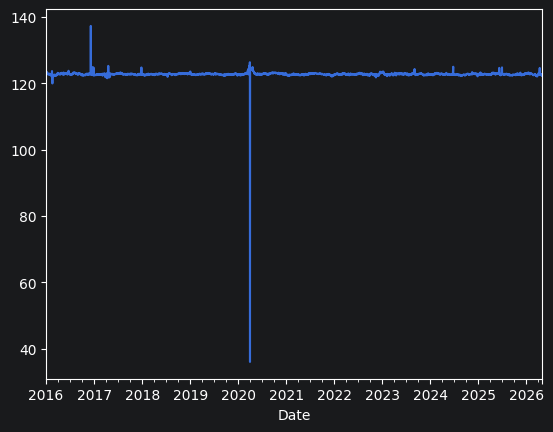

In [55]:
spread.plot()

In [56]:
from statsmodels.tsa.stattools import adfuller

print(adfuller(spread)[1])

0.0


In [57]:
dfa.loc["2020"]

Ticker,AUD,EUR,GBP,NZD,AED,ARS,BRL,CAD,CHF,CLP,...,RON,RUB,SAR,SEK,SGD,THB,TRY,TWD,VND,ZAR
Date,,,,,,,,,,,,,,,,,,,,,
2020-01-01,0.701700,1.122083,1.326260,0.678580,3.672200,59.826630,4.016786,1.300200,0.967200,738.900024,...,4.267600,62.028301,3.746646,9.170810,1.334500,29.680000,5.947800,29.898001,23171.000000,13.995900
2020-01-02,0.701951,1.122083,1.325030,0.673718,3.672200,59.858627,4.016300,1.297300,0.967500,740.099976,...,4.265100,61.830002,3.746979,9.339400,1.345190,30.059999,5.946300,29.844000,23171.000000,14.002920
2020-01-03,0.698519,1.117144,1.315270,0.670021,3.672200,59.798901,4.023400,1.298300,0.971200,749.299988,...,4.276300,61.694199,3.746398,9.361400,1.346900,30.139999,5.955700,29.900000,23171.000000,14.078000
2020-01-04,0.697153,1.116828,1.312850,0.668524,3.672317,59.769800,4.034600,1.298420,0.971293,754.133321,...,4.276030,61.806132,3.748032,9.377493,1.347860,30.141333,5.959787,29.945000,23171.000000,14.158083
2020-01-05,0.695787,1.116512,1.310430,0.667028,3.672433,59.740698,4.045800,1.298540,0.971387,758.966654,...,4.275760,61.918065,3.749666,9.393587,1.348820,30.142666,5.963873,29.990000,23171.000000,14.238166
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2020-12-27,0.761021,1.219830,1.356560,0.712291,3.671393,83.236308,5.215300,1.284247,0.889920,714.299988,...,3.995807,73.979935,3.751462,8.240203,1.328207,30.050001,7.571033,27.997333,23128.333333,14.585000
2020-12-28,0.761191,1.220510,1.357239,0.711561,3.670690,83.226601,5.215300,1.283960,0.889430,714.299988,...,3.996460,73.954903,3.751100,8.256450,1.328620,30.065001,7.569500,27.938999,23130.000000,14.609900
2020-12-29,0.758892,1.222345,1.346602,0.710800,3.672500,83.831596,5.245900,1.284000,0.888300,711.500000,...,3.984400,73.930496,3.748862,8.260510,1.329300,30.139999,7.439400,28.107000,23125.000000,14.622910


In [58]:
(dfa.pct_change().abs() > 0.1).sum()

Ticker
AUD     0
EUR     0
GBP     0
NZD     0
AED     0
ARS     5
BRL     0
CAD     0
CHF     0
CLP     3
CNY     0
COP     2
CZK     0
DKK     0
EGP     5
GHS     7
HKD     0
HUF     0
IDR     0
INR     0
JPY     0
KES     0
KRW     0
KWD     0
KZT     0
MXN     0
MYR     0
NGN    33
NOK     6
PEN     3
PHP     2
PLN     0
QAR     2
RON     0
RUB    17
SAR     2
SEK     0
SGD     0
THB     0
TRY     2
TWD     0
VND     0
ZAR     4
dtype: int64